# 02 — Logistic Regression

**Repository:** `AI_Engineer-DL` | **Section:** `01_neural_networks_and_dl/logistic_regression`  
**File:** `notebooks/02_logistic_regression.ipynb`

> **Prerequisites:** `01_binary_classification.ipynb` — you should be comfortable with  
> the (nₓ, m) layout of X and the (1, m) layout of Y before starting here.
>
> **Core Focus:** You implement the sigmoid function from scratch, understand why it is used  
> instead of a linear output, and build the logistic regression hypothesis ŷ = σ(wᵀx + b).  
> The cost function and gradient descent are deferred to notebooks 03 and 04.

## 1. What Is This?

Logistic regression is the simplest algorithm that learns to separate two classes.  
It takes a feature vector x, computes a weighted sum z = wᵀx + b (exactly like linear regression),  
then squashes z through the sigmoid function to produce a number between 0 and 1 —  
a valid probability that the example belongs to class 1.  
Every neural network's final output layer for binary problems is logistic regression.

**Real-world connection — WaveMamba-DF:** The final layer of your deepfake detector  
takes the deep feature vector produced by EfficientNet-B5 and applies exactly this:  
z = wᵀ·features + b, then σ(z) gives P(deepfake). The backbone learns the features;  
logistic regression on top makes the binary decision.

| Concept | What it is | Why it matters |
|---------|-----------|----------------|
| **w** | Weight vector ∈ ℝⁿˣ — one weight per input feature | Controls how much each feature influences the prediction |
| **b** | Bias scalar ∈ ℝ | Shifts the decision boundary away from the origin |
| **z = wᵀx + b** | The linear pre-activation | The "score" before it becomes a probability |
| **σ(z)** | Sigmoid function — maps ℝ → (0, 1) | Converts an unbounded score into a valid probability |
| **ŷ** | Predicted probability P(y=1\|x) | What the model outputs; compared to true label y |

## 2. The Math

### A — Why not linear regression?

A linear model outputs z = wᵀx + b ∈ ℝ — it can be any real number, including negative  
values or values above 1. This cannot be interpreted as a probability.  
We need a function that squashes any real number into (0, 1).

---

### B — The Sigmoid Function

$$\sigma(z) = \frac{1}{1 + e^{-z}}$$

**Symbol by symbol:**
- $z$ — the linear score: $w^Tx + b$
- $e$ — Euler's number ≈ 2.718
- $e^{-z}$ — exponential decay: large when z is negative, near 0 when z is large
- The whole expression maps z ∈ ℝ to σ(z) ∈ (0, 1)

**Key values:**
- $z \to +\infty$: $e^{-z} \to 0$, so $\sigma(z) \to 1$
- $z \to -\infty$: $e^{-z} \to \infty$, so $\sigma(z) \to 0$
- $z = 0$: $\sigma(0) = \frac{1}{1+1} = 0.5$

**Worked example:** z = 2 → σ(2) = 1/(1 + e⁻²) = 1/(1 + 0.135) ≈ 0.88.  
This means the model is 88% confident the example belongs to class 1.

---

### C — The Sigmoid Derivative (needed for backprop)

$$\frac{d\sigma}{dz} = \sigma(z)\,(1 - \sigma(z))$$

If a = σ(z), then the derivative is simply a·(1 - a).  
**Worked example:** z = 2, a = 0.88 → derivative = 0.88 × (1 - 0.88) = 0.88 × 0.12 ≈ 0.106.

---

### D — The Full Logistic Regression Model

$$\hat{y} = \sigma(w^T x + b) = \frac{1}{1 + e^{-(w^T x + b)}}$$

- $w \in \mathbb{R}^{n_x}$ — weight vector (same dimension as the input)
- $b \in \mathbb{R}$ — bias (scalar)
- $x \in \mathbb{R}^{n_x}$ — input feature vector (one example)
- $\hat{y} \in (0,1)$ — predicted probability

> ⚠️ **Float safety:** When computing σ(z) for very large negative z, `np.exp(-z)`  
> can overflow to infinity. For numerically stable sigmoid, clip z or use  
> `scipy.special.expit`. In this notebook we keep it simple and note the limitation.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

## 3. Build From Scratch

### 3.1 — Sigmoid function

This is the most important function you will implement in this entire section.  
It must work on scalars, vectors, and matrices — NumPy's broadcasting handles this automatically  
if you write it correctly using `np.exp`.

> 🔮 **Predict before you run:** What should `sigmoid(0)` return? What about `sigmoid(100)`  
> and `sigmoid(-100)`? Write the three expected values before writing a single line of code.

In [2]:
# YOUR CODE HERE
# ── Task ─────────────────────────────────────────────────────────────────────
# Implement sigmoid(z) that works on scalars, 1-D arrays, and 2-D arrays.
# Formula: σ(z) = 1 / (1 + exp(-z))
# Do NOT use scipy.special.expit — implement from the formula using np.exp.
#
# After implementing, test on these inputs and print results:
#   sigmoid(0)    → expected: 0.5
#   sigmoid(2)    → expected: ~0.8808
#   sigmoid(-2)   → expected: ~0.1192
#   sigmoid(np.array([-1, 0, 1]))  → expected: [0.269, 0.5, 0.731]
# ─────────────────────────────────────────────────────────────────────────────

def sigmoid(z):
    """
    Compute the sigmoid of z element-wise.
    σ(z) = 1 / (1 + exp(-z))
    Works on scalars, 1-D arrays, and 2-D arrays.
    """
    return 1 / (1 + np.exp(-z))

# ── Tests ────────────────────────────────────────────────────────────────────
print(f"sigmoid(0)    -> {sigmoid(0)}")
print(f"sigmoid(2)    -> {sigmoid(2):.4f}")
print(f"sigmoid(-2)   -> {sigmoid(-2):.4f}")

array_input = np.array([-1, 0, 1])
array_output = sigmoid(array_input)
print(f"sigmoid([-1, 0, 1]) -> {np.round(array_output, 3)}")

sigmoid(0)    -> 0.5
sigmoid(2)    -> 0.8808
sigmoid(-2)   -> 0.1192
sigmoid([-1, 0, 1]) -> [0.269 0.5   0.731]


> 💡 **Reflect:** Notice that sigmoid(-2) ≈ 1 - sigmoid(2). This symmetry around 0.5  
> is a fundamental property of the sigmoid. It tells you the function is "balanced" —  
> confidence of 0.88 for z=2 exactly mirrors doubt of 0.12 for z=-2.

---

### 3.2 — Sigmoid derivative

During backpropagation you will need the derivative of σ(z) with respect to z.  
The elegant result is that it can be expressed purely in terms of the sigmoid output itself.

> 🔮 **Predict before you run:** The derivative formula is σ(z)·(1 - σ(z)).  
> At z = 0, what is the derivative? Is the gradient largest near z=0 or near z=±5? Why?

In [3]:
# YOUR CODE HERE
# ── Task ─────────────────────────────────────────────────────────────────────
# Implement sigmoid_derivative(z).
# Formula: dσ/dz = σ(z) · (1 - σ(z))
# You may call your sigmoid() function inside.
#
# Test:
#   sigmoid_derivative(0)  → expected: 0.25
#   sigmoid_derivative(2)  → expected: ~0.1050
#   sigmoid_derivative(-2) → expected: ~0.1050  (symmetric!)
# ─────────────────────────────────────────────────────────────────────────────

def sigmoid_derivative(z):
    """
    Compute dσ/dz = σ(z) · (1 - σ(z)).
    """
    s = sigmoid(z)
    return s * (1 - s)

# ── Tests ────────────────────────────────────────────────────────────────────
print(f"sigmoid_derivative(0)  -> {sigmoid_derivative(0)}")
print(f"sigmoid_derivative(2)  -> {sigmoid_derivative(2):.4f}")
print(f"sigmoid_derivative(-2) -> {sigmoid_derivative(-2):.4f}")


sigmoid_derivative(0)  -> 0.25
sigmoid_derivative(2)  -> 0.1050
sigmoid_derivative(-2) -> 0.1050


> 💡 **Reflect:** The derivative is highest at z=0 (value 0.25) and falls toward 0  
> for large |z|. This is the vanishing gradient problem in disguise — deep networks  
> with sigmoid activations in hidden layers have near-zero gradients far from 0.  
> This is why ReLU replaced sigmoid in hidden layers (coming in Week 3).

---

### 3.3 — Computing z = wᵀx + b

The pre-activation z is a dot product of the weight vector and the input, plus a bias.  
For a single example x of shape (nₓ, 1), z is a scalar.

> 🔮 **Predict before you run:** If w has shape (nₓ, 1) and x has shape (nₓ, 1),  
> which NumPy operation gives you wᵀx as a scalar? Think about shapes before coding.

In [4]:
# YOUR CODE HERE
# ── Task ─────────────────────────────────────────────────────────────────────
# 1. Set nx = 4 (small for readability).
# 2. Create w of shape (nx, 1) — initialise to zeros using np.zeros.
# 3. Create b = 0.0 (scalar).
# 4. Create a single example x of shape (nx, 1) — use np.array([[1],[2],[3],[4]]).
# 5. Compute z = w.T @ x + b    (use the @ operator for matrix multiply)
# 6. Print z and z.shape.
# Expected result: z = [[0.]] shape (1,1) — because w is all zeros.
# ─────────────────────────────────────────────────────────────────────────────

# ── Solution ─────────────────────────────────────────────────────────────────

# 1. Set nx = 4
nx = 4

# 2. Create w of shape (nx, 1) — initialise to zeros
w = np.zeros((nx, 1))

# 3. Create b = 0.0 (scalar)
b = 0.0

# 4. Create a single example x of shape (nx, 1)
x = np.array([[1], [2], [3], [4]])

# 5. Compute z = w.T @ x + b
z = w.T @ x + b

# 6. Print z and z.shape
print(f"z = {z}")
print(f"z.shape = {z.shape}")

z = [[0.]]
z.shape = (1, 1)


### 3.4 — Full forward pass: ŷ = σ(wᵀx + b)

Combine steps 3.3 and 3.1 into one function.  
This is the complete logistic regression prediction for a single example.

> 🔮 **Predict before you run:** With w = zeros and b = 0, what will ŷ always be,  
> regardless of the input x? Why? Think about what σ(0) equals.

In [5]:
# YOUR CODE HERE
# ── Task ─────────────────────────────────────────────────────────────────────
# Implement predict(x, w, b) that returns ŷ = σ(wᵀx + b).
# x: shape (nx, 1), w: shape (nx, 1), b: scalar.
# Returns: ŷ as a scalar (or shape (1,1) — either is acceptable).
#
# Test with:
#   x = np.array([[1.0], [0.5], [-1.0], [2.0]])
#   w = np.array([[0.1], [-0.2], [0.3], [0.05]])
#   b = -0.1
# Compute z manually first: z = 0.1*1 + (-0.2)*0.5 + 0.3*(-1) + 0.05*2 - 0.1
# Then verify your function matches.
# ─────────────────────────────────────────────────────────────────────────────

def predict(x, w, b):
    """
    Logistic regression forward pass for one example.
    Returns ŷ = σ(wᵀx + b).
    """
    # Compute the linear pre-activation
    z = w.T @ x + b
    
    # Apply the sigmoid activation function
    y_hat = sigmoid(z)
    
    return y_hat

# ── Tests ────────────────────────────────────────────────────────────────────
x = np.array([[1.0], [0.5], [-1.0], [2.0]])
w = np.array([[0.1], [-0.2], [0.3], [0.05]])
b = -0.1

# Manual computation of z
# z = (0.1 * 1.0) + (-0.2 * 0.5) + (0.3 * -1.0) + (0.05 * 2.0) - 0.1
# z = 0.1 - 0.1 - 0.3 + 0.1 - 0.1 = -0.3
z_manual = -0.3
y_hat_manual = sigmoid(z_manual)

# Function computation
y_hat_function = predict(x, w, b)

print(f"Manual z            = {z_manual}")
print(f"Manual ŷ            = {y_hat_manual}")
print(f"predict(x, w, b) ŷ  = {y_hat_function[0, 0]}")

Manual z            = -0.3
Manual ŷ            = 0.425557483188341
predict(x, w, b) ŷ  = 0.425557483188341


> ✅ **Self-check:** Before moving on:
> 1. What are the shapes of w, b, x, z, and ŷ for a single example with nₓ = 12288?
> 2. Why is the sigmoid derivative highest at z = 0 and what does that mean for training?

## 4. Library Version

`scipy.special.expit` is the numerically stable sigmoid. Verify your scratch implementation matches it.

In [6]:
from scipy.special import expit

test_values = np.array([-5, -2, -1, 0, 1, 2, 5], dtype=float)

scratch  = sigmoid(test_values)
library  = expit(test_values)
match    = np.allclose(scratch, library)

print("z values:       ", test_values)
print("scratch σ(z):   ", np.round(scratch, 6))
print("scipy  σ(z):    ", np.round(library, 6))
print(f"All close: {match}")

z values:        [-5. -2. -1.  0.  1.  2.  5.]
scratch σ(z):    [0.006693 0.119203 0.268941 0.5      0.731059 0.880797 0.993307]
scipy  σ(z):     [0.006693 0.119203 0.268941 0.5      0.731059 0.880797 0.993307]
All close: True


## 5. Visualisation

### 5.1 — Sigmoid curve and its derivative

Two panels: the sigmoid shape and its gradient. Together they show why  
the sigmoid is a probability squasher and where it causes vanishing gradients.

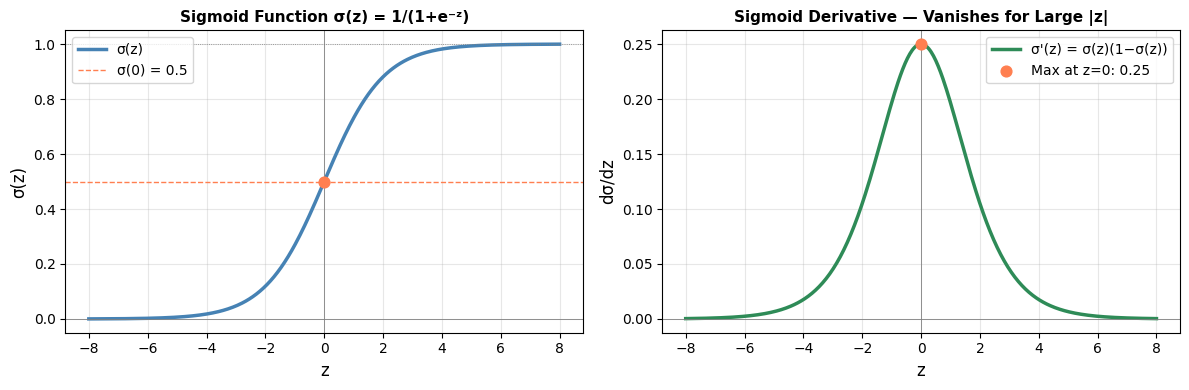

Saved → ../images/02_logistic_regression_sigmoid.png


In [7]:
import os
os.makedirs('../images', exist_ok=True)

z_range = np.linspace(-8, 8, 400)
sig     = sigmoid(z_range)
sig_d   = sigmoid_derivative(z_range)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Left: sigmoid
axes[0].plot(z_range, sig, color='steelblue', lw=2.5, label='σ(z)')
axes[0].axhline(0.5, color='coral', lw=1, ls='--', label='σ(0) = 0.5')
axes[0].axvline(0,   color='grey',  lw=0.6)
axes[0].axhline(0,   color='grey',  lw=0.6)
axes[0].axhline(1,   color='grey',  lw=0.6, ls=':')
axes[0].scatter([0], [0.5], color='coral', zorder=5, s=60)
axes[0].set_xlabel('z', fontsize=12)
axes[0].set_ylabel('σ(z)', fontsize=12)
axes[0].set_title('Sigmoid Function σ(z) = 1/(1+e⁻ᶻ)', fontsize=11, fontweight='bold')
axes[0].legend(fontsize=10)
axes[0].grid(alpha=0.3)
axes[0].set_ylim(-0.05, 1.05)

# Right: derivative
axes[1].plot(z_range, sig_d, color='seagreen', lw=2.5, label="σ'(z) = σ(z)(1−σ(z))")
axes[1].axvline(0, color='grey', lw=0.6)
axes[1].axhline(0, color='grey', lw=0.6)
axes[1].scatter([0], [0.25], color='coral', zorder=5, s=60, label='Max at z=0: 0.25')
axes[1].set_xlabel('z', fontsize=12)
axes[1].set_ylabel("dσ/dz", fontsize=12)
axes[1].set_title('Sigmoid Derivative — Vanishes for Large |z|', fontsize=11, fontweight='bold')
axes[1].legend(fontsize=10)
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig('../images/02_logistic_regression_sigmoid.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved → ../images/02_logistic_regression_sigmoid.png')

## 6. Revision Corner

---

### One-sentence definition

> Logistic regression computes ŷ = σ(wᵀx + b), where σ is the sigmoid function  
> that maps the linear score z = wᵀx + b to a probability in (0, 1) that the input belongs to class 1.

---

### Why it exists — what problem does it solve?

Linear regression outputs unbounded real numbers — useless as probabilities.  
Logistic regression wraps the linear model in a sigmoid to constrain the output to (0, 1),  
making it interpretable as a probability and enabling it to be trained with a proper  
probabilistic loss function (cross-entropy). It is the mathematical bridge between  
a raw numeric score and a probabilistic prediction.

---

### Interview gotchas

| Question | Common mistake | The reality |
|----------|---------------|-------------|
| **Why sigmoid and not just threshold at 0.5?** | "Threshold is simpler" | A hard threshold has zero gradient everywhere — you cannot train it with gradient descent. Sigmoid is smooth, so gradients flow and weights update. |
| **What does the bias b do?** | "It's optional" | Without b, the decision boundary must pass through the origin. b shifts it. Without b, the model cannot separate classes whose dividing line doesn't cross the origin. |
| **What is the derivative of σ(z)?** | Forget or look it up | σ(z)·(1 − σ(z)). If a = σ(z), the derivative is a·(1−a). Memorise this — you write it dozens of times in backprop. |
| **Why does sigmoid cause vanishing gradients?** | "It doesn't" | For |z| > 5, the derivative approaches 0. In deep networks, multiplying near-zero gradients at each layer causes the gradient to vanish before reaching early layers. |
| **What's the difference between w and W?** | Confuse scalar and matrix notation | Lowercase w is the weight vector for a single neuron (nₓ, 1). Uppercase W is the weight matrix for a layer with multiple neurons. Here in logistic regression, w is lowercase. |

## 7. Exercises

Write your solutions in `exercises/02_logistic_regression_exN_label.py`.

---

### ⭐ Exercise 1 — Sigmoid from scratch, verified

Implement `sigmoid(z)` using only `np.exp` (no scipy).  
Test it on: scalars -10, 0, 10; a vector `np.linspace(-3, 3, 7)`; a (2,3) matrix.  
Verify every result against `scipy.special.expit` using `np.allclose`.  
Also implement and test `sigmoid_derivative(z)` — verify at z=0 the value is exactly 0.25.

*Expected: all np.allclose checks print True.*

---

### ⭐⭐ Exercise 2 — Logistic regression predictions on a mini dataset

Use seed 42. Create a mini dataset: nₓ=3, m=6.  
Initialise w = np.array([[0.5], [-0.3], [0.8]]) and b = 0.1.  
Generate X = np.random.randn(3, 6) and binary labels Y = np.random.randint(0, 2, (1, 6)).  
1. Compute z = wᵀX + b for all 6 examples at once (matrix form — no loop).  
2. Compute ŷ = σ(z) for all 6 examples.  
3. Threshold at 0.5 to get binary predictions: ŷ_class = (ŷ >= 0.5).astype(int).  
4. Compute accuracy = fraction of correct predictions vs Y.  
Print z (shape 1,6), ŷ (shape 1,6), ŷ_class, and accuracy.

---

### ⭐⭐⭐ Exercise 3 — Decision boundary visualisation

**Scenario:** You have 2-feature input data (nₓ=2) so you can plot it in 2D.  
The decision boundary of logistic regression is the line where σ(wᵀx + b) = 0.5 → wᵀx + b = 0.

1. Use seed 0. Create class-1 data: 50 points sampled from N([2,2], I).  
   Create class-0 data: 50 points sampled from N([-2,-2], I).  
   Stack into X (shape 2,100) and Y (shape 1,100).
2. Set w = np.array([[1.0],[1.0]]) and b = 0.0.
3. Compute ŷ for all 100 examples.
4. Plot: scatter the two classes in different colours (steelblue for y=1, coral for y=0).  
   Draw the decision boundary line (where w[0]*x1 + w[1]*x2 + b = 0).  
   Label axes x₁ and x₂, add title and legend.
5. Save to `../images/02_logistic_regression_exercise.png`.
6. Answer in a comment: what would happen to the decision boundary if you doubled w?